# Panorama Stitching

Our project belongs to the area of computer vision and image processing, specifically panoramic image stitching. 

The goal of this project is to construct an automated panorama stitching pipeline from overlapping images. Panorama stitching combines several images of the same scene into one wide image by detecting common points, matching them, estimating the geometric transformation between the images, and warping one image into the coordinate system of the other.

The complete pipeline consists of the following stages:

1. Loading the images
2. Converting images to grayscale
3. Reducing noise using Gaussian smoothing
4. Detecting keypoints (Harris corner algorithm and ORB)
5. Extracting and matching feature descriptors
6. Estimating the homography matrix
7. Removing outliers with RANSAC
8. Warping and stitching the images into a panorama

## Imports

The implementation uses the following libraries:

- `cv2` for image processing and computer vision algorithms
- `numpy` for matrix operations
- `matplotlib` for visualization
- `time` for runtime analysis

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

## Helper Functions

To make the notebook more readable, helper functions are defined for displaying color and grayscale images.

In [2]:
def show_image(img, title="Image", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

## Image Loading

The input images are stored in a local folder named `images`.  
For successful panorama stitching, the images must contain overlapping regions of the same scene.

In [ ]:
# Paths to input images
img1_path = "images/test1/img1.jpg"
img2_path = "images/test1/img2.jpg"

# Load images
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

box = cv2.imread("box.png")
scene = cv2.imread("box-in-scene.png")

# Check that images were loaded correctly
if img1 is None or img2 is None:
    print("Error: One or both images could not be loaded. Check file paths.")
else:
    print("Images loaded successfully.")
    print("Image 1 shape:", img1.shape)
    print("Image 2 shape:", img2.shape)

Images loaded successfully.
Image 1 shape: (1000, 664, 3)
Image 2 shape: (1000, 664, 3)


The loaded images are displayed to verify that the correct files were read.

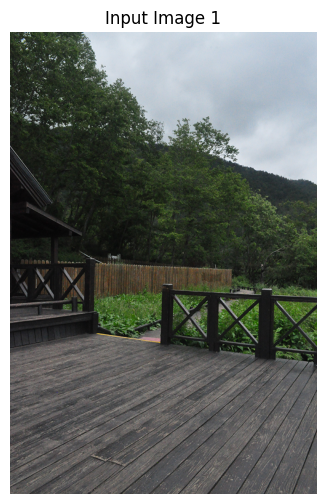

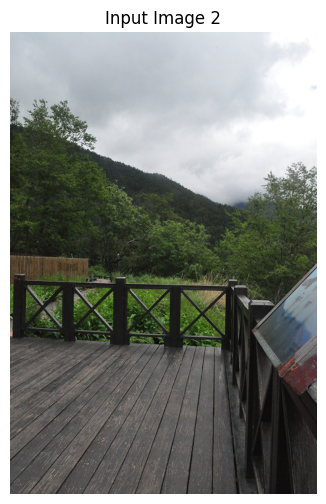

In [4]:
show_image(img1, "Input Image 1")
show_image(img2, "Input Image 2")

## Grayscale Conversion

Most feature detection methods operate on image intensity rather than color. Therefore, each image is converted from RGB/BGR to grayscale.

The color image $I_{RGB}$ exists in a 3-dimensional space:

$$
I_{RGB} \in \mathbb{R}^{H \times W \times 3}
$$

Each pixel at coordinates $(x, y)$, where $x \in \{1, 2, \dots, W\}$ and $y \in \{1, 2, \dots, H\}$, the pixel is represented by a vector of three color values:

$$
c(x,y) = \begin{bmatrix} R(x,y) \\ G(x,y) \\ B(x,y) \end{bmatrix}
$$

The grayscale pixel intensity $Y(x,y)$ for a single pixel is calculated via the dot product of the weight vector and the color vector:

$$Y(x,y) = w^\top c(x,y) = \begin{bmatrix} 0.299 & 0.587 & 0.114 \end{bmatrix} \begin{bmatrix} R(x,y) \\ G(x,y) \\ B(x,y) \end{bmatrix}$$

By applying this transformation across all coordinates $(x,y)$, the color dimension is eliminated. The resulting grayscale image $I_{gray}$ is now a 2-dimensional matrix:

$$I_{gray} \in \mathbb{R}^{H \times W}$$

The entire image is now represented by this matrix, where every element is a pixel intensity:

$$I_{gray} = \begin{bmatrix} Y(1,1) & Y(1,2) & \dots & Y(1,W) \\ Y(2,1) & Y(2,2) & \dots & Y(2,W) \\ \vdots & \vdots & \ddots & \vdots \\ Y(H,1) & Y(H,2) & \dots & Y(H,W) \end{bmatrix}$$

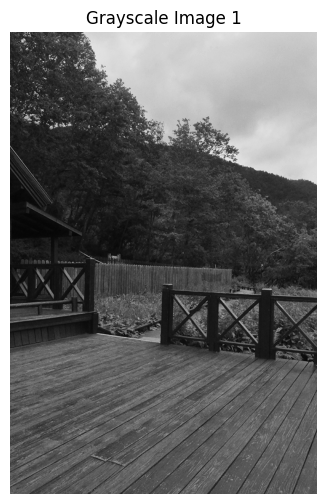

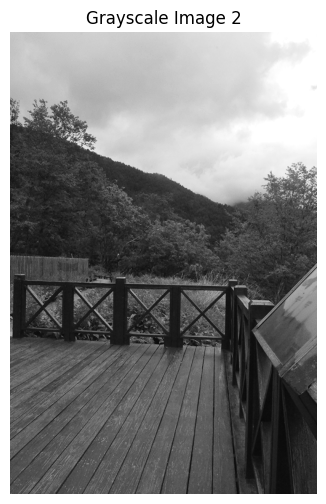

In [5]:
# Convert images to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

show_gray(gray1, "Grayscale Image 1")
show_gray(gray2, "Grayscale Image 2")

## Gaussian Smoothing

Before feature detection, images are often smoothed to reduce noise and small-scale intensity variations that could produce unstable or false features. Gaussian smoothing performs this task by convolving the image with a Gaussian kernel.

Gaussian smoothing is defined as a convolution of the image with a Gaussian kernel:

$$
I_s(x,y) = G(x,y) * I(x,y)
$$

where the Gaussian function is

$$
G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}.
$$

For digital images, the convolution is computed over a finite neighborhood around each pixel. The smoothed image intensity at location $(x,y)$ is given by:

$$I_s(x,y) = \sum_{u=-k}^{k} \sum_{v=-k}^{k} G(u,v)I(x-u,y-v)$$

where:
* $I(x,y)$ is the original grayscale image
* $I_s(x,y)$ is the smoothed image
* $G(u,v)$ is the sampled Gaussian kernel
* $(2k+1) \times (2k+1)$ is the kernel size

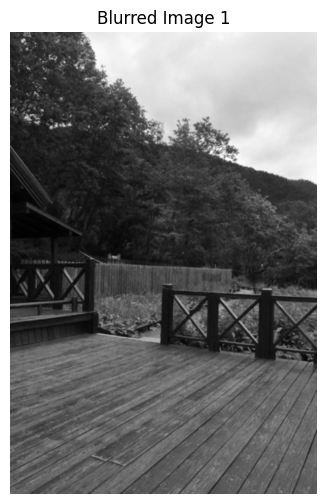

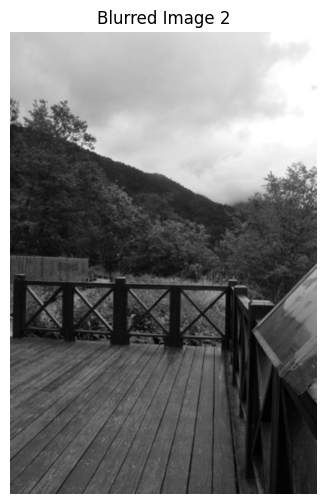

In [6]:
# Apply Gaussian blur
blur1 = cv2.GaussianBlur(gray1, (5, 5), 1.0)
blur2 = cv2.GaussianBlur(gray2, (5, 5), 1.0)

show_gray(blur1, "Blurred Image 1")
show_gray(blur2, "Blurred Image 2")

## Harris Corner Detector

The Harris Corner Detector was introduced by Chris Harris and Mike Stephens in 1988 in the paper “A Combined Corner and Edge Detector”. The Harris Corner Detector is a classical algorithm used to identify interest points (corners) in an image. A corner is a point whose local neighborhood is characterized by large intensity variation in all directions.

### Compute Derivatives
To measure intensity changes, we compute the partial derivatives of the image with respect to $x$ and $y$. 

In practice, these derivatives are approximated using **Sobel operators**:

* $I_x$: Gradient in the x-direction

$$
I_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix} * I
$$

* $I_y$: Gradient in the y-direction

$$
I_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix} * I
$$

These gradients describe how the image intensity changes locally in horizontal and vertical directions.

### Compute Gradient Products
Calculate the products of the derivatives for every pixel to capture the intensity variations:
* $I_x^2 = I_x \cdot I_x$
* $I_y^2 = I_y \cdot I_y$
* $I_{xy} = I_x \cdot I_y$

### Construction of the Harris Matrix
To determine if a region contains a corner, we need to look at the gradients over a local neighborhood (a window) rather than just a single pixel. We apply a window function, $w(x,y)$, which is typically a Gaussian filter, to compute the weighted sum of the gradient products.

In our implementation, we use `cv2.GaussianBlur` to achieve this:

* $S_{xx} = w(x,y) * I_x^2$
* $S_{yy} = w(x,y) * I_y^2$
* $S_{xy} = w(x,y) * I_{xy}$

These smoothed values are used to construct the Harris Matrix, $M$, for each pixel:

$$M = \begin{bmatrix} S_{xx} & S_{xy} \\ S_{xy} & S_{yy} \end{bmatrix}$$

### Compute the Harris Response
The eigenvalues of the matrix $M$ ($\lambda_1$ and $\lambda_2$) determine whether a region is flat, an edge, or a corner:

* **Flat region:** Both $\lambda_1$ and $\lambda_2$ are small.
* **Edge:** One eigenvalue is large, and the other is small.
* **Corner:** Both $\lambda_1$ and $\lambda_2$ are large.


Because computing eigenvalues for every single pixel is computationally expensive, the response function $R$, was introduced, that uses the determinant and trace of $M$:

$$R = \det(M) - k \cdot (\text{trace}(M))^2$$

Where:
* $\det(M) = \lambda_1 \lambda_2 = S_{xx}S_{yy} - S_{xy}^2$
* $\text{trace}(M) = \lambda_1 + \lambda_2 = S_{xx} + S_{yy}$
* $k$ is an empirically determined constant, usually in the range of **0.04 to 0.06**.

To filter out weak responses, a threshold $T$ is applied:

$$
R(x,y) > T
$$

Only pixels exceeding this threshold are considered potential corners.

### Non-Maximum Suppression

After thresholding, multiple neighboring pixels may correspond to the same corner. To retain only the most significant points, **non-maximum suppression (NMS)** is applied.

A pixel is considered a corner if:

$$
R(x,y) = \max_{\text{local neighborhood}} R
$$

This ensures that:
- only local maxima are preserved
- each corner is represented by a single point
- clusters of responses are eliminated

In [7]:
def harris_corner_detector_custom(img, k=0.04, window_size=3, threshold_ratio=0.01):
    """
    Custom Harris Corner Detector implementation.
    
    img: Input grayscale image (preferably already blurred).
    k: Harris detector free parameter.
    window_size: Size of the Gaussian window.
    threshold_ratio: Ratio to threshold the maximum Harris response.
    """
    # 1. Calculate spatial derivatives (gradients) using Sobel
    Ix = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # 2. Calculate products of derivatives
    Ixx = Ix ** 2
    Iyy = Iy ** 2
    Ixy = Ix * Iy

    # 3. Apply a Gaussian window to compute sums of the products
    Sxx = cv2.GaussianBlur(Ixx, (window_size, window_size), 0)
    Syy = cv2.GaussianBlur(Iyy, (window_size, window_size), 0)
    Sxy = cv2.GaussianBlur(Ixy, (window_size, window_size), 0)

    # 4. Calculate the Harris response R
    det_M = (Sxx * Syy) - (Sxy ** 2)
    trace_M = Sxx + Syy
    R = det_M - k * (trace_M ** 2)

    # 5. Non-maximum suppression and thresholding
    local_max = cv2.dilate(R, None)
    
    # Define threshold based on the maximum response
    threshold = threshold_ratio * R.max()
    
    # Create an empty map for the corners
    corners = np.zeros_like(R, dtype=np.uint8)
    
    # A pixel is a corner if it's a local maximum and exceeds the threshold
    corners[(R > threshold) & (R == local_max)] = 255

    return R, corners

In [8]:
start = time.time()

R1, corners1 = harris_corner_detector_custom(blur1, k=0.04, window_size=3, threshold_ratio=0.01)
R2, corners2 = harris_corner_detector_custom(blur2, k=0.04, window_size=3, threshold_ratio=0.01)

end = time.time()
harris_time = end - start

def draw_corners(original_img, corner_map):
    img_out = original_img.copy() 
    visible_corners = cv2.dilate(corner_map, None, iterations=3)
    
    img_out[visible_corners == 255] = [0, 0, 255] 
    return img_out

img1_corners = draw_corners(img1, corners1)
img2_corners = draw_corners(img2, corners2)

### Harris Corner Detection Results and Observations

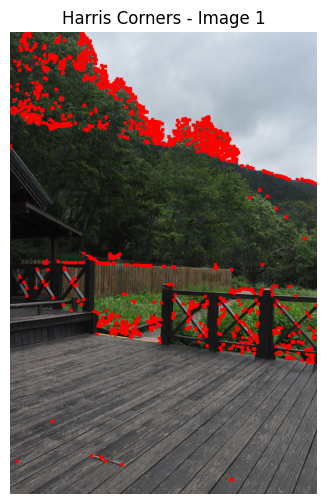

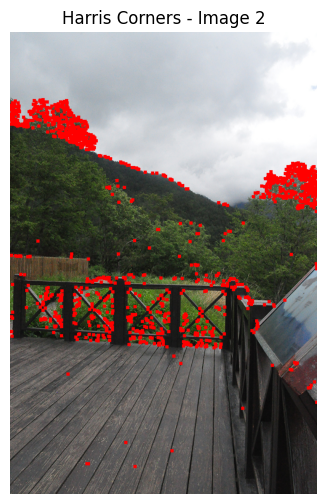

Harris Corner Detection Summary
Number of detected corners in Image 1: 1348
Number of detected corners in Image 2: 1168
Processing time: 0.0365 seconds


In [9]:
num_corners1 = np.sum(corners1 == 255)
num_corners2 = np.sum(corners2 == 255)

show_image(img1_corners, "Harris Corners - Image 1")
show_image(img2_corners, "Harris Corners - Image 2")

print("Harris Corner Detection Summary")
print(f"Number of detected corners in Image 1: {num_corners1}")
print(f"Number of detected corners in Image 2: {num_corners2}")
print(f"Processing time: {harris_time:.4f} seconds")

From the visualized results, the detected corners are concentrated around textured regions, object boundaries, and distinctive structural details. This behavior is expected, since such regions produce strong variations in both horizontal and vertical directions. Compared to flat regions, where the image intensity remains nearly constant, corners produce significantly larger positive values of the Harris response.

## ORB (Oriented FAST and Rotated BRIEF)

ORB (Oriented FAST and Rotated BRIEF) is a feature detection and description algorithm designed as a fast. It combines the FAST detector for finding keypoints and the BRIEF descriptor for describing local image patches around these points.

The FAST part is responsible for detecting visually distinctive points, usually corners or high-contrast local structures. However, FAST alone does not provide a descriptor and is not rotation invariant. To solve this, ORB assigns an orientation to each detected keypoint based on the intensity distribution in its local neighborhood.

After that, ORB computes a rotated version of the BRIEF descriptor. BRIEF is a binary descriptor formed by comparing intensities of selected pairs of pixels in a small image patch. Because the descriptor is binary, it is very compact and can be matched efficiently using Hamming distance.

In [ ]:
def detect_orb_features(img, nfeatures=1000, title=None, visualize=False):
    #Step 1. Convert the input image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #Step 2. Create the ORB detector
    orb = cv2.ORB_create(nfeatures=nfeatures)

    #Step 3. Detect keypoints and compute descriptors
    kp, des = orb.detectAndCompute(gray, None)

    #Step 4. Visualize detected ORB keypoints on the original image
    orb_img = cv2.drawKeypoints(
        img, kp, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    if visualize and title is not None:
        show_image(orb_img, title)

    return kp, des, orb_img

In [38]:
def show_orb_keypoints(img1, nfeatures=1000):
    kp_orb, des_orb, orb_img = detect_orb_features(
        img1, nfeatures=nfeatures, title="ORB Keypoints - Image", visualize=False
    )

    show_image(orb_img, "ORB Keypoints - Image")
    return kp_orb, des_orb, orb_img

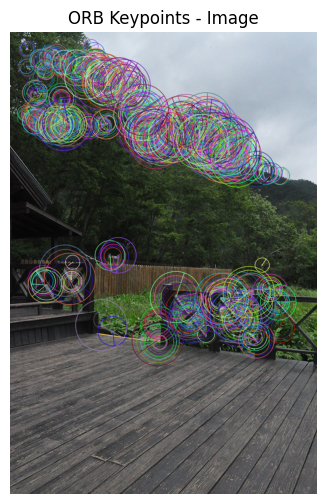

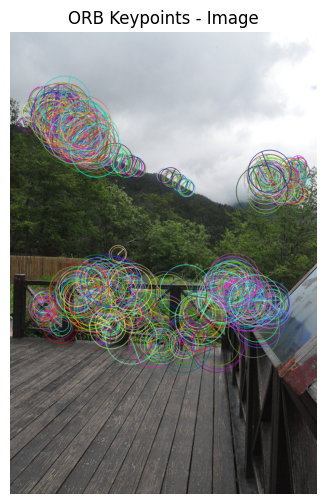

In [39]:
kp_orb, des_orb, orb_img, = show_orb_keypoints(img1)
kp_orb, des_orb, orb_img, = show_orb_keypoints(img2)

### How ORB works step by step

1. **Convert both input images to grayscale.**

   ORB performs detection and descriptor computation on grayscale images because intensity information is sufficient for local feature analysis.

2. **Detect keypoints using FAST.**

   FAST finds pixels whose local neighborhood changes sharply, which usually indicates corners or other distinctive points.

3. **Assign orientation to each keypoint.**

   ORB estimates the dominant direction of the local patch, which makes the keypoint representation rotation-aware.

4. **Compute BRIEF descriptors.**

   For each keypoint, ORB builds a binary descriptor by comparing intensities of selected pixel pairs in the local patch.

5. **Match descriptors between the two images.**

   Since BRIEF descriptors are binary, the similarity between descriptors is measured using Hamming distance.

6. **Sort matches by descriptor distance.**

   Smaller distance means the descriptors are more similar, so these matches are usually more reliable.

7. **Keep the best matches.**

   The strongest correspondences are selected and can later be used for homography estimation and panorama stitching.

### ORB matching

After detecting keypoints and computing descriptors for both images, the next step is to find correspondences between them. In this implementation, descriptor matching is performed with a brute-force matcher using Hamming distance, which is appropriate for binary ORB descriptors.

a descriptor in the first image must consider a descriptor in the second image its best match, and vice versa. This usually reduces false matches and gives a cleaner set of correspondences, although sometimes it also reduces the total number of matches.

The best matches are then sorted by descriptor distance. Lower distance indicates greater descriptor similarity, so these matches are considered more reliable. The strongest matches can later be used for homography estimation.

In [ ]:
def detect_features_and_match_orb(img1, img2, nFeaturesReturn=40, nfeatures=1000):
    #Step 1. Detect ORB keypoints and descriptors for both images
    kp1, des1, _ = detect_orb_features(img1, nfeatures=nfeatures, visualize=False)
    kp2, des2, _ = detect_orb_features(img2, nfeatures=nfeatures, visualize=False)

    #Step 2. Check whether descriptors were found
    if des1 is None or des2 is None:
        return None, None, None, None, None

    #Step 3. Create the brute-force matcher for binary ORB descriptors
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    #Step 4. Match descriptors
    matches = bf.match(des1, des2)

    #Step 5. Sort matches by distance
    matches = sorted(matches, key=lambda x: x.distance)

    #Step 6. Keep only the best matches
    matches = matches[:nFeaturesReturn]

    #Step 7. Build point correspondences
    src = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    return kp1, kp2, matches, src, dst

In [41]:
def show_orb_matches(img1, img2, kp1, kp2, matches, title="ORB Matches"):
    matched_img = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    show_image(matched_img, title)

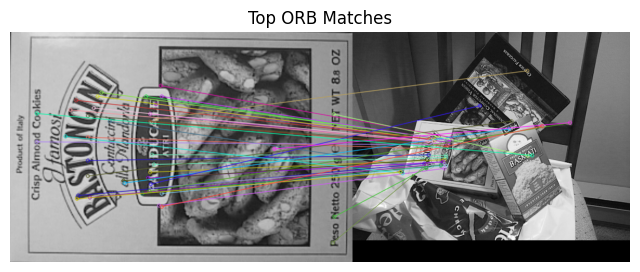

ORB Matching Summary
Number of matches shown: 40
src_orb shape: (40, 1, 2)
dst_orb shape: (40, 1, 2)


In [ ]:
kp1_match, kp2_match, matches_orb, src_orb, dst_orb = detect_features_and_match_orb(
    box, scene, nFeaturesReturn=40
)

if matches_orb is None:
    print("Descriptors were not found for one or both images.")
else:
    show_orb_matches(box, scene, kp1_match, kp2_match, matches_orb, "Top ORB Matches")

    print("ORB Matching Summary")
    print(f"Number of matches shown: {len(matches_orb)}")
    print(f"src_orb shape: {src_orb.shape}")
    print(f"dst_orb shape: {dst_orb.shape}")

After detecting ORB keypoints and computing binary descriptors for both images, the next step is to match descriptors between them. 

For this, we use a brute-force matcher with Hamming distance, which is appropriate for binary ORB descriptors.

The matches are sorted by descriptor distance, and the best correspondences are selected.

These matched points can later be used to estimate a homography and align the images in the panorama stitching pipeline.